<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/%EC%9A%94%EC%9D%BC%EB%B3%84_%EB%A6%AC%EB%93%AC_%EB%B6%84%EC%84%9D_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (51.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

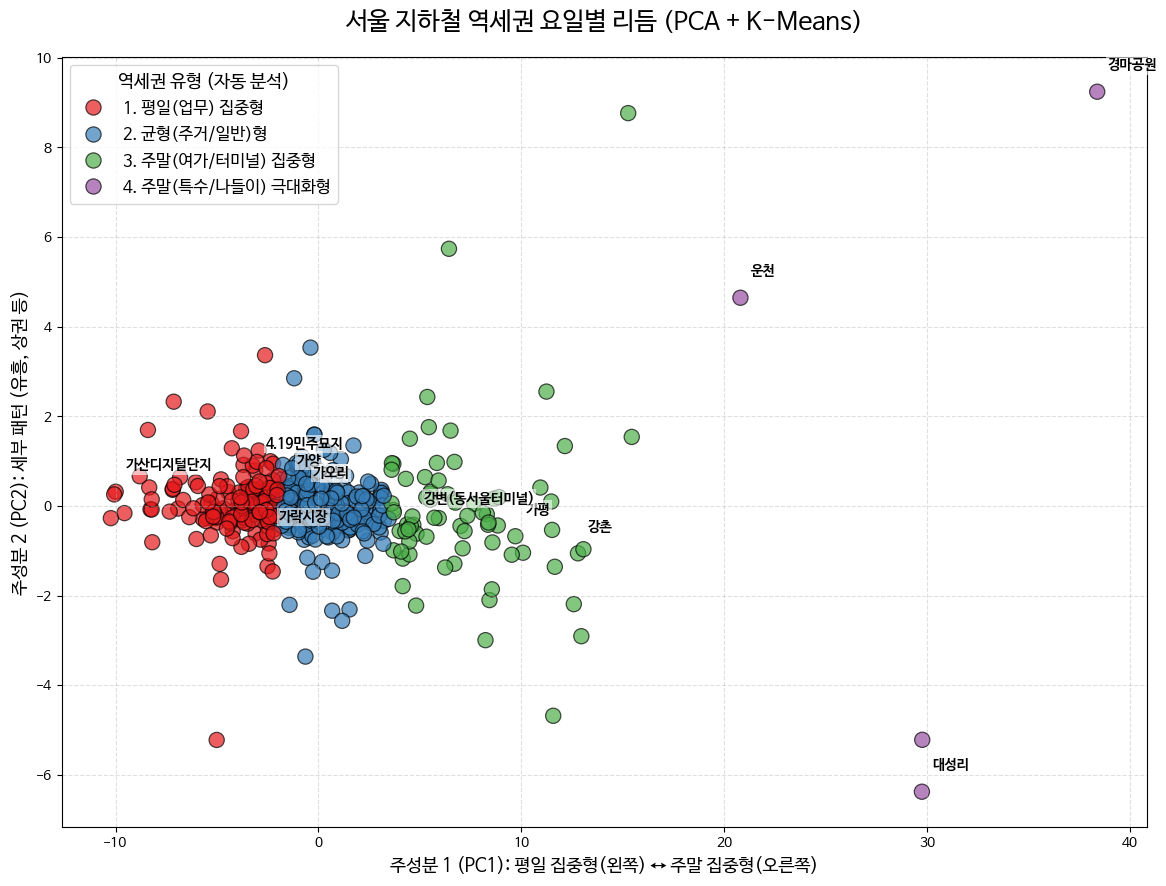


[알고리즘 자동 분석 결과: 클러스터별 특성]
▶ 1. 평일(업무) 집중형 (총 172개 역): 4.19민주묘지, 가락시장, 가산디지털단지, 가천대, 갈매, 강남, 강남구청, 강동구청, 강매, 개롱 ...
▶ 2. 균형(주거/일반)형 (총 277개 역): 가능, 가양, 가오리, 가좌, 간석, 강동, 강일, 개봉, 개화산, 건대입구 ...
▶ 3. 주말(여가/터미널) 집중형 (총 75개 역): 가평, 강변(동서울터미널), 강촌, 고속터미널, 관악산(서울대), 굴봉산, 김유정, 김포공항, 남춘천, 녹사평(용산구청) ...
▶ 4. 주말(특수/나들이) 극대화형 (총 4개 역): 경마공원, 대성리, 운천, 임진강 ...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. 코랩 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (열 밀림 방지)
file_path = 'CARD_SUBWAY_MONTH_202605.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8', header=None, skiprows=1).iloc[:, :5]
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp949', header=None, skiprows=1).iloc[:, :5]

df.columns = ['사용일자', '노선명', '역명', '승차총승객수', '하차총승객수']
df['역명'] = df['역명'].astype(str).str.strip()

# 3. 데이터 전처리
df['총이용객'] = df['승차총승객수'] + df['하차총승객수']
df['사용일자'] = pd.to_datetime(df['사용일자'].astype(str), format='%Y%m%d')
df['요일'] = df['사용일자'].dt.day_name()

# 4. 요일별 패턴 정규화
pivot = df.pivot_table(index='역명', columns='요일', values='총이용객', aggfunc='mean').fillna(0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[day_order]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.fillna(0)

# 5. K-Means 군집화 진행
kmeans = KMeans(n_clusters=4, random_state=42)
pivot_pct['Cluster'] = kmeans.fit_predict(pivot_pct)

# ====================================================================
# ★ 핵심: 클러스터 번호(0~3)에 자동으로 의미 있는 이름표 붙이기
# 각 클러스터의 '토요일+일요일 비중'을 계산해서 성격을 정의합니다.
# ====================================================================
cluster_centers = pivot_pct.groupby('Cluster')[day_order].mean()
cluster_centers['주말비중'] = cluster_centers['Saturday'] + cluster_centers['Sunday']

# 주말 비중이 낮은 순서(평일 집중)부터 높은 순서(주말 집중)로 이름 매핑
sorted_clusters = cluster_centers.sort_values('주말비중').index.tolist()
label_mapping = {
    sorted_clusters[0]: '1. 평일(업무) 집중형',
    sorted_clusters[1]: '2. 균형(주거/일반)형',
    sorted_clusters[2]: '3. 주말(여가/터미널) 집중형',
    sorted_clusters[3]: '4. 주말(특수/나들이) 극대화형'
}
pivot_pct['클러스터 유형'] = pivot_pct['Cluster'].map(label_mapping)

# 6. PCA (주성분 분석)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(pivot_pct[day_order])

pivot_pct['PC1'] = pca_features[:, 0]
pivot_pct['PC2'] = pca_features[:, 1]

# 7. 군집 산점도(Scatter Plot) 시각화
plt.figure(figsize=(14, 10))

# 범례 순서를 깔끔하게 지정
order_labels = ['1. 평일(업무) 집중형', '2. 균형(주거/일반)형', '3. 주말(여가/터미널) 집중형', '4. 주말(특수/나들이) 극대화형']

# hue를 '클러스터 유형' 텍스트로 지정하여 범례에 바로 한글이 뜨게 만듦
sns.scatterplot(x='PC1', y='PC2', hue='클러스터 유형', hue_order=order_labels, palette='Set1',
                data=pivot_pct, s=120, alpha=0.7, edgecolor='black')

# 각 군집별 대표적인 역 이름 표시
for cluster_id in range(4):
    sample_stations = pivot_pct[pivot_pct['Cluster'] == cluster_id].head(3).index
    for station in sample_stations:
        x_val = pivot_pct.loc[station, 'PC1']
        y_val = pivot_pct.loc[station, 'PC2']
        plt.text(x_val + 0.5, y_val + 0.5, station, fontsize=10, weight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title('서울 지하철 역세권 요일별 리듬 (PCA + K-Means)', fontsize=18, pad=20)
plt.xlabel('주성분 1 (PC1): 평일 집중형(왼쪽) ↔ 주말 집중형(오른쪽)', fontsize=13)
plt.ylabel('주성분 2 (PC2): 세부 패턴 (유흥, 상권 등)', fontsize=13)
plt.legend(title='역세권 유형 (자동 분석)', fontsize=12, title_fontsize=13, loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.show()

# ==========================================
# 8. 클러스터별 텍스트 요약 출력
# ==========================================
print("\n[알고리즘 자동 분석 결과: 클러스터별 특성]")
for label in order_labels:
    stations = pivot_pct[pivot_pct['클러스터 유형'] == label].index.tolist()
    print(f"▶ {label} (총 {len(stations)}개 역): {', '.join(stations[:10])} ...")